### Figure 5. Test the hypothesis that theta sequences extending towards the end removes extra graph paths.
Matrix style
Oct 25, 2025

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (figure4_master, save_remote_animal_figure4,
            load_remote_animal_figure4, remote_theta_count_per_day, long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindTheta

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

[2025-10-28 15:18:49,752][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[15:18:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:18:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:18:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:18:57][WARNING] Spyglass: Deprecation: this class has b

In [16]:
from spyglass.shijiegu.changeOfMind_deltat import count_by_day

In [5]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}
transition_to_investigate = {}
other_transition_to_investigate = {}

In [269]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

transition_to_investigate[animal] = [(2,1),(3,4)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)], (3,4):[(3,1),(3,2)]}

animal = "lewis"
animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

transition_to_investigate[animal] = [(4,3),(1,2)]
other_transition_to_investigate[animal] = {(4,3): [(4,1)],(1,2):[(1,3),(1,4)]}

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024']
seq_animals[animal] = 'seq2'

transition_to_investigate[animal] = [(2,1), (3,4)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)],
                                            (3,4): [(3,1)]}

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']
transition_to_investigate[animal] = [(4,3)]
other_transition_to_investigate[animal] = {(4,3): [(4,2)]}
seq_animals[animal] = 'rev2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807']

transition_to_investigate[animal] = [(2,1)]
other_transition_to_investigate[animal] = {(2,1): [(2,3),(2,4)]}
seq_animals[animal] = 'seq2'


[16:42:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:42:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:42:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [270]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure5/'

def return_save_name(animal, d1, d2):
    save_name = f'{animal.lower()}_{d1}_{d2}_figure5m'
    return save_name

### Make data

In [271]:
import statsmodels.api as sm
def regression_routine(X, y):
    
    # Create a DataFrame for easier handling with statsmodels formula API
    df = pd.DataFrame({'X': X, 'y': y})
    
    # 2. Perform Linear Regression with statsmodels
    # Add a constant to the independent variable for the intercept
    X_const = sm.add_constant(X)
    
    # Fit the OLS model
    model = sm.OLS(y, X_const)
    results = model.fit()
    
    # 3. Plotting the regression line and displaying p-value
    Y_pred = results.predict(X_const)
    
    # Get the p-value for the independent variable (X)
    # The p-value for the constant (intercept) is at index 0, for X at index 1
    p_value_X = results.pvalues[1]

    return X, Y_pred, p_value_X

In [175]:
animal = "klein"

list_of_days = list_of_days_animals[animal]

(com_initial_count, com_final_count, com_theta_count, behavior_count,
 com_initial_N, com_final_N, com_theta_N, behavior_N) = count_by_day(animal, list_of_days)

data = {}
data["com_initial_count"] = com_initial_count
data["com_final_count"] = com_final_count
data["com_theta_count"] = com_theta_count
data["behavior_count"] = behavior_count
data["com_initial_N"] = com_initial_N
data["com_final_N"] = com_final_N
data["com_theta_N"] = com_theta_N
data["behavior_N"] = behavior_N

save_name = return_save_name(animal, list_of_days[0], list_of_days[-1])
file_path = output_folder + save_name + '.pkl'

with open(file_path, 'wb') as file:
    print("data saved to " + file_path)
    pickle.dump(data, file, protocol = pickle.HIGHEST_PROTOCOL)

[2025-10-29 10:03:01,422][WARNING]: Skipped checksum for file with hash: 7dc653d3-716c-1006-6f9e-a97d4391fd7f, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_T3OEH3NRFS.nwb


klein20231101_.nwb


[2025-10-29 10:03:12,544][WARNING]: Skipped checksum for file with hash: 89d15458-0f8f-61e8-d1a9-93226c35e106, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_260WQY1J5H.nwb
[2025-10-29 10:03:21,937][WARNING]: Skipped checksum for file with hash: 1ba56d31-5342-6865-9898-dae1a3159ada, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_07WK1VR39D.nwb
[2025-10-29 10:03:31,430][WARNING]: Skipped checksum for file with hash: 1fc34d62-05f6-66e0-e269-ac4ffe88eac9, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_PGWQK2PZCZ.nwb
[2025-10-29 10:03:41,175][WARNING]: Skipped checksum for file with hash: 752997b3-a7ed-63ba-e93c-be729636e9fb, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_6RT16A8Z7N.nwb
[2025-10-29 10:03:50,751][WARNING]: Skipped checksum for file with hash: 9cf4f491-1458-c116-a13a-8bac1e206520, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_953IPNBDQY.nwb
[2025-10-29 10:04:00,103][WARNING]: Skipped checksum for file with hash: a5

klein20231102_.nwb


[2025-10-29 10:04:09,750][WARNING]: Skipped checksum for file with hash: c99a4e38-72e0-0d38-30b2-893a112ebae6, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_0605MSYX6O.nwb
[2025-10-29 10:04:19,624][WARNING]: Skipped checksum for file with hash: c9a570b2-b046-dbce-42c5-991db0d59c76, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_25WQVF9CQG.nwb
[2025-10-29 10:04:29,109][WARNING]: Skipped checksum for file with hash: 24bea014-b41c-5065-1a65-f99239050868, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_1SZU3OH9Q0.nwb
[2025-10-29 10:04:38,231][WARNING]: Skipped checksum for file with hash: a775e9cc-d7cd-841d-efb3-cc7ee57f5892, and path: /stelmo/nwb/analysis/klein20231102/klein20231102_15MABO0TIC.nwb
[2025-10-29 10:04:47,411][WARNING]: Skipped checksum for file with hash: 7c37600b-09ae-f6ec-b8ad-19bceaa824d9, and path: /stelmo/nwb/analysis/klein20231103/klein20231103_SZYWP0H3ZR.nwb


...

klein20231109_.nwb


[2025-10-29 10:09:30,521][WARNING]: Skipped checksum for file with hash: aa4b88bf-b38e-d714-fc74-61b4c7ed796f, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_UQFCFP9AV5.nwb
[2025-10-29 10:09:39,614][WARNING]: Skipped checksum for file with hash: c77a2ac7-6fef-1819-ac7c-5f7c6915f509, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_XHHZCB6PSI.nwb
[2025-10-29 10:09:48,873][WARNING]: Skipped checksum for file with hash: 9d9ad985-8b25-45fa-380d-d631d40a1f75, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_87YVLHTJ2Z.nwb
[2025-10-29 10:09:58,092][WARNING]: Skipped checksum for file with hash: 86b81795-0200-db1b-f059-9cb460915ca9, and path: /stelmo/nwb/analysis/klein20231109/klein20231109_2XAZJM0QNS.nwb
[2025-10-29 10:10:07,102][WARNING]: Skipped checksum for file with hash: b5e240c7-f1ac-37c6-5e1c-86f066ddffdb, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_6H2H9L7RQ6.nwb


klein20231111_.nwb


[2025-10-29 10:10:16,233][WARNING]: Skipped checksum for file with hash: cd021f6c-59fa-eea0-7848-f52b0ac191fa, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_VRPVHTI1X0.nwb
[2025-10-29 10:10:25,443][WARNING]: Skipped checksum for file with hash: 6f0a2a55-7cf5-769c-b18b-16585017c4b2, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_30MMHG7OV3.nwb
[2025-10-29 10:10:34,573][WARNING]: Skipped checksum for file with hash: d50b346f-ad42-bf72-7ce9-c39ae03821db, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_FXY6K59G0V.nwb
[2025-10-29 10:10:43,755][WARNING]: Skipped checksum for file with hash: ec4fc7ed-f1ea-8a34-e5fb-6b4a4fdb0327, and path: /stelmo/nwb/analysis/klein20231111/klein20231111_RR46U6QBXA.nwb


data saved to /stelmo/shijie/change_of_mind_analysis/figure5/klein_20231101_20231111_figure5m.pkl


### Load and plot

In [281]:
animal = "klein"

In [282]:
list_of_days = list_of_days_animals[animal]

save_name = return_save_name(animal, list_of_days[0], list_of_days[-1])
file_path = output_folder + save_name + '.pkl'
with open(file_path, 'rb') as file:
    print("data loaded " + file_path)
    loaded_data = pickle.load(file)

(com_initial_count, com_final_count, com_theta_count, behavior_count,
 com_initial_N, com_final_N, com_theta_N, behavior_N) = (loaded_data["com_initial_count"],
                                                         loaded_data["com_final_count"],
                                                         loaded_data["com_theta_count"],
                                                         loaded_data["behavior_count"],
                                                         loaded_data["com_initial_N"],
                                                         loaded_data["com_final_N"],
                                                         loaded_data["com_theta_N"],
                                                         loaded_data["behavior_N"])

data loaded /stelmo/shijie/change_of_mind_analysis/figure5/klein_20231101_20231108_figure5m.pkl


In [283]:
com_initial_count.keys()

dict_keys(['20231101', '20231102', '20231103', '20231104', '20231105', '20231106', '20231107', '20231108', '20231109', '20231111'])

Text(0.5, 1.0, 'all days')

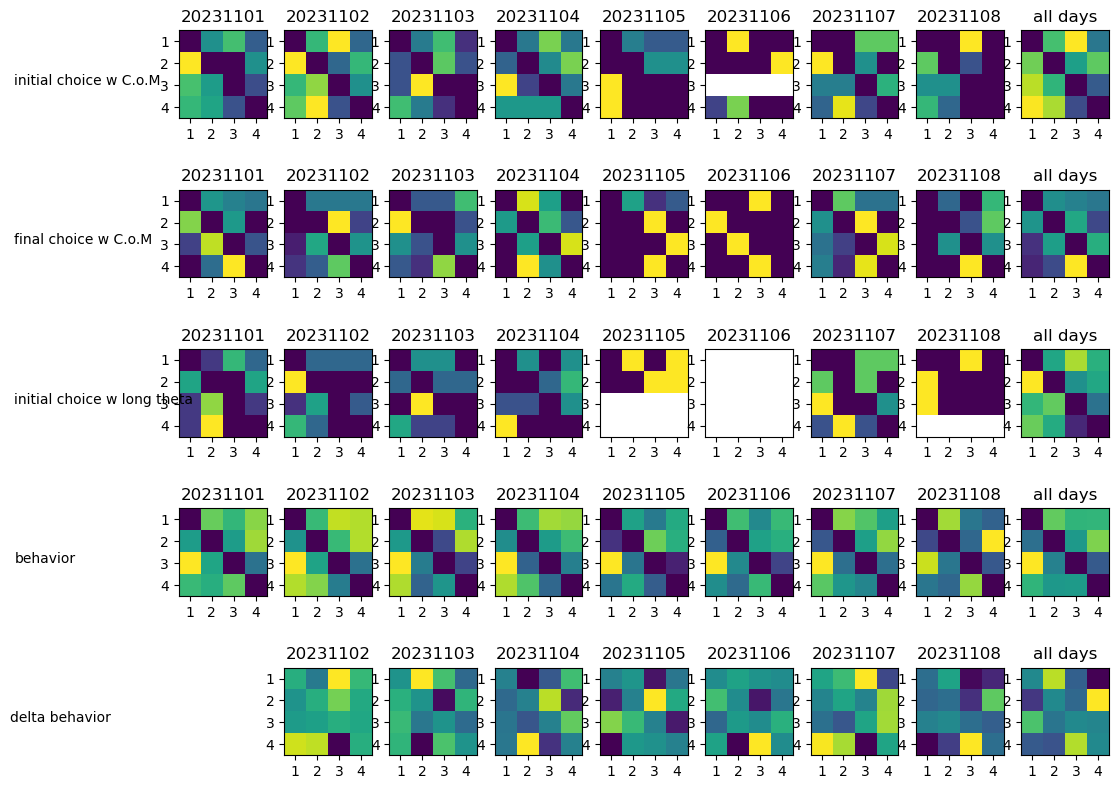

In [284]:
days_to_plot = list_of_days
fig, axes = plt.subplots(5,len(days_to_plot) + 1,figsize = (1.5 * len(days_to_plot), 10))
for d_ind in range(len(days_to_plot)):
    d = days_to_plot[d_ind]

    row_ind = 0
    axes[row_ind,d_ind].imshow(com_initial_count[d])
    axes[row_ind,d_ind].set_xticks(np.arange(4))
    axes[row_ind,d_ind].set_yticks(np.arange(4))
    axes[row_ind,d_ind].set_xticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_yticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_title(str(d))
    if d_ind == 0:
        axes[row_ind,0].text(-8,2, "initial choice w C.o.M")
    
    row_ind = 1
    axes[row_ind,d_ind].imshow(com_final_count[d])
    axes[row_ind,d_ind].set_xticks(np.arange(4))
    axes[row_ind,d_ind].set_yticks(np.arange(4))
    axes[row_ind,d_ind].set_xticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_yticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_title(str(d))
    if d_ind == 0:
        axes[row_ind,0].text(-8,2, "final choice w C.o.M")
    
    row_ind = 2
    axes[row_ind,d_ind].imshow(com_theta_count[d])
    axes[row_ind,d_ind].set_xticks(np.arange(4))
    axes[row_ind,d_ind].set_yticks(np.arange(4))
    axes[row_ind,d_ind].set_xticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_yticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_title(str(d))
    if d_ind == 0:
        axes[row_ind,0].text(-8,2,"initial choice w long theta" )

    row_ind = 3
    axes[row_ind,d_ind].imshow(behavior_count[d])
    axes[row_ind,d_ind].set_xticks(np.arange(4))
    axes[row_ind,d_ind].set_yticks(np.arange(4))
    axes[row_ind,d_ind].set_xticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_yticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_title(str(d))
    if d_ind == 0:
        axes[row_ind,0].text(-8,2,"behavior")

    row_ind = 4
    if d_ind == 0:
        axes[row_ind,d_ind].set_axis_off()
        continue
    axes[row_ind,d_ind].imshow(behavior_count[d] - behavior_count[days_to_plot[d_ind-1]])
    axes[row_ind,d_ind].set_xticks(np.arange(4))
    axes[row_ind,d_ind].set_yticks(np.arange(4))
    axes[row_ind,d_ind].set_xticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_yticklabels(np.arange(4)+1)
    axes[row_ind,d_ind].set_title(str(d))
    if d_ind == 1:
        axes[row_ind,1].text(-13,2,"delta behavior")


row_ind = 0
com_initial_count_matrix = np.stack([com_initial_count[d] for d in days_to_plot],axis = 2)
com_initial_count_matrix = np.nansum(com_initial_count_matrix, axis = 2) / len(days_to_plot)
axes[row_ind,-1].imshow(com_initial_count_matrix)
axes[row_ind,-1].set_xticks(np.arange(4))
axes[row_ind,-1].set_yticks(np.arange(4))
axes[row_ind,-1].set_xticklabels(np.arange(4)+1)
axes[row_ind,-1].set_yticklabels(np.arange(4)+1)
axes[row_ind,-1].set_title("all days")

row_ind = 1
com_final_count_matrix = np.stack([com_final_count[d] for d in days_to_plot],axis = 2)
com_final_count_matrix = np.nansum(com_final_count_matrix, axis = 2) / len(days_to_plot)
axes[row_ind,-1].imshow(com_final_count_matrix)
axes[row_ind,-1].set_xticks(np.arange(4))
axes[row_ind,-1].set_yticks(np.arange(4))
axes[row_ind,-1].set_xticklabels(np.arange(4)+1)
axes[row_ind,-1].set_yticklabels(np.arange(4)+1)
axes[row_ind,-1].set_title("all days")

row_ind = 2
com_theta_count_matrix = np.stack([com_theta_count[d] for d in days_to_plot],axis = 2)
com_theta_count_matrix = np.nansum(com_theta_count_matrix, axis = 2) / len(days_to_plot)
axes[row_ind,-1].imshow(com_theta_count_matrix)
axes[row_ind,-1].set_xticks(np.arange(4))
axes[row_ind,-1].set_yticks(np.arange(4))
axes[row_ind,-1].set_xticklabels(np.arange(4)+1)
axes[row_ind,-1].set_yticklabels(np.arange(4)+1)
axes[row_ind,-1].set_title("all days")

row_ind = 3
com_behavior_count_matrix = np.stack([behavior_count[d] for d in days_to_plot],axis = 2)
com_behavior_count_matrix = np.nansum(com_behavior_count_matrix, axis = 2) / len(days_to_plot)
axes[row_ind,-1].imshow(com_behavior_count_matrix)
axes[row_ind,-1].set_xticks(np.arange(4))
axes[row_ind,-1].set_yticks(np.arange(4))
axes[row_ind,-1].set_xticklabels(np.arange(4)+1)
axes[row_ind,-1].set_yticklabels(np.arange(4)+1)
axes[row_ind,-1].set_title("all days")

row_ind = 4
#behavior_count_matrix = np.stack([behavior_count[d] for d in days_to_plot],axis = 2)
#behavior_count_matrix = np.nansum(behavior_count_matrix, axis = 2) / len(days_to_plot)
behavior_count_matrix = behavior_count[days_to_plot[-1]] - behavior_count[days_to_plot[0]]
axes[row_ind,-1].imshow(behavior_count_matrix)
axes[row_ind,-1].set_xticks(np.arange(4))
axes[row_ind,-1].set_yticks(np.arange(4))
axes[row_ind,-1].set_xticklabels(np.arange(4)+1)
axes[row_ind,-1].set_yticklabels(np.arange(4)+1)
axes[row_ind,-1].set_title("all days")

Text(0, 0.1, 'klein')

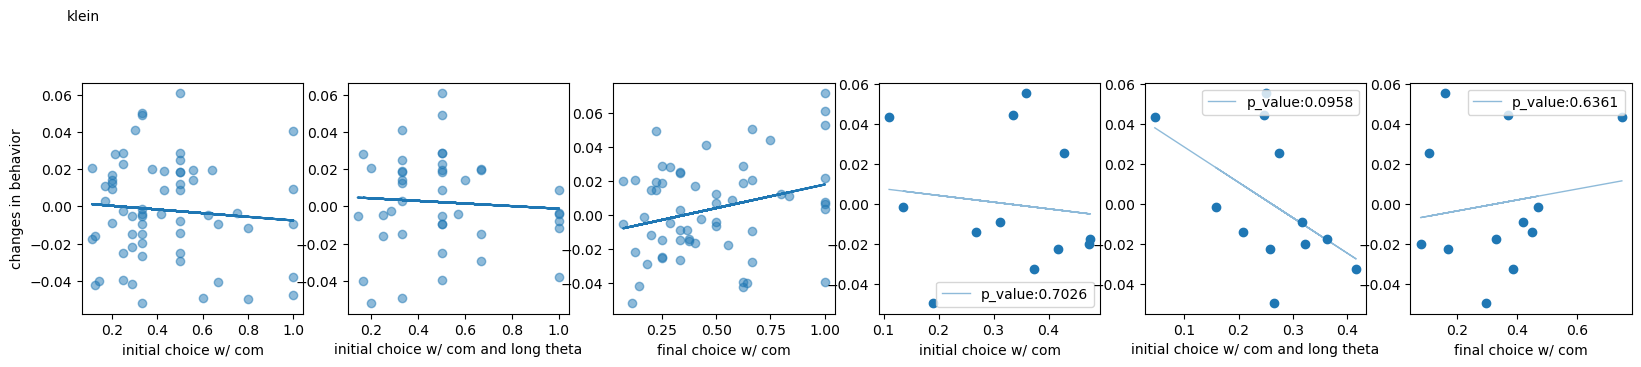

In [285]:
### scatter plot among all days
days_to_plot = list_of_days

fig, axes = plt.subplots(1,6,figsize = (20, 3))
# 1. y: delta behavior x: initial choice w/ com
# 2. y: delta behavior x: initial choice w/ com and theta
# 3. y: delta behavior x: final choice w/com

com_initial = []
com_theta = []
com_final = []
com_initial_y = []
com_theta_y = []
com_final_y = []

diagonal_mask = np.eye(4, dtype=bool)
off_diagonal_mask = ~diagonal_mask

for d_ind in range(1,len(days_to_plot)):
    d = days_to_plot[d_ind]
    
    x = com_initial_count[d][off_diagonal_mask]
    x = x.ravel()
    
    y = behavior_count[days_to_plot[d_ind]] - behavior_count[days_to_plot[d_ind-1]]
    y = y[off_diagonal_mask].ravel()
    
    if com_initial_N[d] >= 5:
        nan_ind = np.logical_or(np.isnan(x), x == 0)
        com_initial.append(x[~nan_ind])
        com_initial_y.append(y[~nan_ind])
        axes[0].scatter(x[~nan_ind],y[~nan_ind],c='C0',alpha = 0.5)

    x = com_theta_count[d][off_diagonal_mask]
    x = x.ravel()
    if com_theta_N[d] >= 5:
        nan_ind = np.logical_or(np.isnan(x), x == 0)
        com_theta.append(x[~nan_ind])
        com_theta_y.append(y[~nan_ind])
        axes[1].scatter(x[~nan_ind],y[~nan_ind],c='C0',alpha = 0.5)

    x = com_final_count[d][off_diagonal_mask]
    x = x.ravel()
    if com_final_N[d] >= 5:
        nan_ind = np.logical_or(np.isnan(x), x == 0)
        com_final.append(x[~nan_ind])
        com_final_y.append(y[~nan_ind])
        axes[2].scatter(x[~nan_ind],y[~nan_ind],c='C0',alpha = 0.5)

axes[0].set_xlabel("initial choice w/ com")
axes[1].set_xlabel("initial choice w/ com and long theta")
axes[2].set_xlabel("final choice w/ com")

for ind in range(1):
    axes[ind].set_ylabel("changes in behavior")


### first 3 axes
y = np.concatenate(com_initial_y).ravel()
X = np.concatenate(com_initial).ravel()
X, Y_pred, p_value_X = regression_routine(X, y)
axes[0].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}")

try: # sometimes there are not enough trials
    y = np.concatenate(com_theta_y).ravel()
    X = np.concatenate(com_theta).ravel()
    X, Y_pred, p_value_X = regression_routine(X, y)
    axes[1].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}")
except:
    pass


y = np.concatenate(com_final_y).ravel()
X = np.concatenate(com_final).ravel()
X, Y_pred, p_value_X = regression_routine(X, y)
axes[2].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}")


behavior_count_matrix = behavior_count[days_to_plot[-1]] - behavior_count[days_to_plot[0]]
behavior_count_matrix = behavior_count_matrix[off_diagonal_mask]

com_initial_count_matrix = np.stack([com_initial_count[d] for d in days_to_plot],axis = 2)
com_initial_count_matrix = np.nansum(com_initial_count_matrix, axis = 2) / len(days_to_plot)
X = com_initial_count_matrix[off_diagonal_mask]

y = behavior_count_matrix
X, Y_pred, p_value_X = regression_routine(X, y)
axes[3].scatter(X, y)
axes[3].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[3].set_xlabel("initial choice w/ com")

com_theta_count_matrix = np.stack([com_theta_count[d] for d in days_to_plot],axis = 2)
com_theta_count_matrix = np.nansum(com_theta_count_matrix, axis = 2) / len(days_to_plot)
X = com_theta_count_matrix[off_diagonal_mask]
X, Y_pred, p_value_X = regression_routine(X, y)
axes[4].scatter(X, y)
axes[4].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[4].set_xlabel("initial choice w/ com and long theta")

com_final_count_matrix = np.stack([com_final_count[d] for d in days_to_plot],axis = 2)
com_final_count_matrix = np.nansum(com_final_count_matrix, axis = 2) / len(days_to_plot)
X = com_final_count_matrix[off_diagonal_mask]
X, Y_pred, p_value_X = regression_routine(X, y)
axes[5].scatter(X, y)
axes[5].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[5].set_xlabel("final choice w/ com")

axes[3].legend()
axes[4].legend()
axes[5].legend()

axes[0].text(0,0.1,animal, fontsize = 10)

### merge all rats

In [274]:
Y = []
X_initial = []
X_initial_theta = []
X_final = []

animal_list = ["eliot","molly","lewis","julio","klein"]
for animal in animal_list:
    days_to_plot = list_of_days_animals[animal]
    
    save_name = return_save_name(animal, days_to_plot[0], days_to_plot[-1])
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        print("data loaded " + file_path)
        loaded_data = pickle.load(file)
    
    (com_initial_count, com_final_count, com_theta_count, behavior_count,
     com_initial_N, com_final_N, com_theta_N, behavior_N) = (loaded_data["com_initial_count"],
                                                             loaded_data["com_final_count"],
                                                             loaded_data["com_theta_count"],
                                                             loaded_data["behavior_count"],
                                                             loaded_data["com_initial_N"],
                                                             loaded_data["com_final_N"],
                                                             loaded_data["com_theta_N"],
                                                             loaded_data["behavior_N"])

    ### get 
    # 1. y: delta behavior x: initial choice w/ com
    # 2. y: delta behavior x: initial choice w/ com and theta
    # 3. y: delta behavior x: final choice w/com

    behavior_count_matrix = behavior_count[days_to_plot[-1]] - behavior_count[days_to_plot[0]]
    behavior_count_matrix = behavior_count_matrix[off_diagonal_mask]
    y = behavior_count_matrix
    Y.append(y)
    
    com_initial_count_matrix = np.stack([com_initial_count[d] for d in days_to_plot],axis = 2)
    com_initial_count_matrix = np.nansum(com_initial_count_matrix, axis = 2) / len(days_to_plot)
    X = com_initial_count_matrix[off_diagonal_mask]
    X_initial.append(X)
    
    
    com_theta_count_matrix = np.stack([com_theta_count[d] for d in days_to_plot],axis = 2)
    com_theta_count_matrix = np.nansum(com_theta_count_matrix, axis = 2) / len(days_to_plot)
    X = com_theta_count_matrix[off_diagonal_mask]
    X_initial_theta.append(X)
    
    
    com_final_count_matrix = np.stack([com_final_count[d] for d in days_to_plot],axis = 2)
    com_final_count_matrix = np.nansum(com_final_count_matrix, axis = 2) / len(days_to_plot)
    X = com_final_count_matrix[off_diagonal_mask]
    X_final.append(X)


data loaded /stelmo/shijie/change_of_mind_analysis/figure5/eliot_20221018_20221024_figure5m.pkl
data loaded /stelmo/shijie/change_of_mind_analysis/figure5/molly_20220416_20220420_figure5m.pkl
data loaded /stelmo/shijie/change_of_mind_analysis/figure5/lewis_20240105_20240110_figure5m.pkl
data loaded /stelmo/shijie/change_of_mind_analysis/figure5/julio_20230731_20230807_figure5m.pkl
data loaded /stelmo/shijie/change_of_mind_analysis/figure5/klein_20231101_20231108_figure5m.pkl


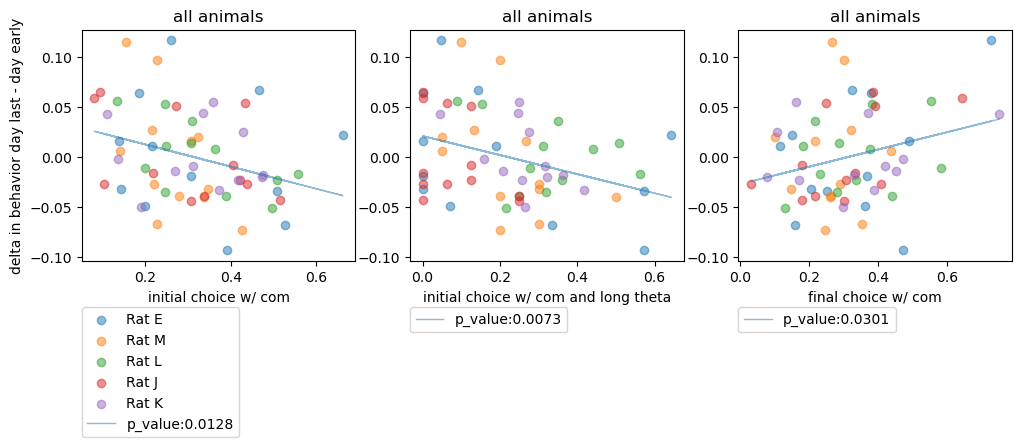

In [275]:
fig, axes = plt.subplots(1,3,figsize = (12, 3))


for animal_ind in range(len(X_initial)):
    axes[0].scatter(X_initial[animal_ind], Y[animal_ind], color = 'C'+str(animal_ind), alpha = 0.5, label = "Rat " + animal_list[animal_ind][0].upper())
X = np.array(X_initial).ravel()
y = np.array(Y).ravel()
X, Y_pred, p_value_X = regression_routine(X, y)

axes[0].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[0].set_xlabel("initial choice w/ com")

for animal_ind in range(len(X_initial_theta)):
    axes[1].scatter(X_initial_theta[animal_ind], Y[animal_ind], color = 'C'+str(animal_ind), alpha = 0.5)
X = np.array(X_initial_theta).ravel()
X, Y_pred, p_value_X = regression_routine(X, y)
axes[1].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[1].set_xlabel("initial choice w/ com and long theta")

for animal_ind in range(len(X_final)):
    axes[2].scatter(X_final[animal_ind], Y[animal_ind], color = 'C'+str(animal_ind), alpha = 0.5)
X = np.array(X_final).ravel()
X, Y_pred, p_value_X = regression_routine(X, y)
axes[2].plot(X, Y_pred, label = f"p_value:{np.round(p_value_X,4)}", alpha = 0.5, linewidth = 1)
axes[2].set_xlabel("final choice w/ com")

axes[0].legend(bbox_to_anchor=(0, -0.2), loc='upper left', borderaxespad=0.)
axes[1].legend(bbox_to_anchor=(0, -0.2), loc='upper left', borderaxespad=0.)
axes[2].legend(bbox_to_anchor=(0, -0.2), loc='upper left', borderaxespad=0.)

axes[0].set_ylabel("delta in behavior day last - day early")

axes[0].set_title("all animals")
axes[1].set_title("all animals")
axes[2].set_title("all animals")

plt.savefig("merged.pdf")
plt.savefig("merged.png")